In [1]:
!pip install requests pillow

In [3]:
!pip install matplotlib

  Using cached contourpy-1.3.1-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-win_amd64.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.8 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 4.8 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.1 MB 4.9 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 4.6 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 4.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.6 MB/s eta 0:00:00
Using cached contourpy-1.3.1-cp3

In [ ]:
# Install required libraries if not already installed
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "pillow"])

# Import libraries
import requests
import os
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import base64

# Set your Hugging Face API key (replace with your actual key)
HUGGINGFACE_API_KEY = ""
API_URL = "https://api-inference.huggingface.co/models/runwayml/stable-diffusion-v1-5"

# Sample prompt to test image generation
prompt = "A hyperrealistic painting of a mountain landscape at sunset, vibrant colors, serene atmosphere"

# Headers with API key
headers = {"Authorization": f"Bearer {HUGGINGFACE_API_KEY}"}

# Payload for the API request
payload = {
    "inputs": prompt,
    "num_images": 3,  # Request 3 images
    "wait_for_model": True  # Ensure the model processes the request
}

# Make the API request
try:
    response = requests.post(API_URL, headers=headers, json=payload, timeout=30)
    response.raise_for_status()  # Raise an error for bad status codes
    
    # Parse the response
    images_data = response.json()
    print("API Response:", images_data)
    
    # Display images (assuming response contains base64 strings or URLs)
    if isinstance(images_data, list) and all(isinstance(img, dict) for img in images_data):
        images = []
        for img_data in images_data:
            if 'image' in img_data:
                image = Image.open(BytesIO(base64.b64decode(img_data['image'])))
            elif 'url' in img_data:
                image_response = requests.get(img_data['url'])
                image = Image.open(BytesIO(image_response.content))
            else:
                print("Unexpected image format, skipping...")
                continue
            images.append(image)
    else:
        print("Unexpected response format, attempting to parse as single image...")
        if isinstance(images_data, str):  # Single base64 string
            images = [Image.open(BytesIO(base64.b64decode(images_data)))] * 3
        else:
            raise ValueError("Unable to parse image data")
    
    # Display the images
    plt.figure(figsize=(15, 5))
    for i, image in enumerate(images[:3], 1):
        plt.subplot(1, 3, i)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f'Image {i}')
    plt.show()
    
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
except ValueError as e:
    print(f"Value Error: {e}")
except Exception as e:
    print(f"Unexpected Error: {e}")

Error: Expecting value: line 1 column 1 (char 0)


Status Code: 200
Raw Response Content Length: 19672 bytes


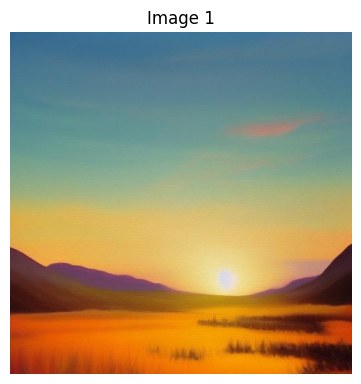

In [ ]:
# Install required libraries if not already installed
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "pillow"])

# Import libraries
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import base64

# Set your Hugging Face API key
HUGGINGFACE_API_KEY = ""
API_URL = "https://api-inference.huggingface.co/models/runwayml/stable-diffusion-v1-5"

# Sample prompt to test image generation
prompt = "A hyperrealistic painting of a mountain landscape at sunset, vibrant colors, serene atmosphere"

# Headers with API key
headers = {"Authorization": f"Bearer {HUGGINGFACE_API_KEY}"}

# Payload for the API request
payload = {
    "inputs": prompt,
    "num_images": 3,  # Request 3 images
    "wait_for_model": True  # Ensure the model processes the request
}

# Make the API request
try:
    response = requests.post(API_URL, headers=headers, json=payload, timeout=60)  # Increased timeout
    print(f"Status Code: {response.status_code}")
    print(f"Raw Response Content Length: {len(response.content)} bytes")  # Debug content length
    
    # Check if response contains image data
    if response.status_code == 200 and response.content:
        # For multiple images, the API might return a list of bytes or a single concatenated response
        # Assuming a single response with multiple images (common behavior), split if needed
        images = []
        image_data = response.content  # Raw binary data
        if len(image_data) > 0:
            # Try to load as a single image first
            try:
                image = Image.open(BytesIO(image_data))
                images.append(image)
            except Exception as e:
                print(f"Error loading single image: {e}")
                # If single image fails, assume multiple images concatenated (less common)
                # Split into 3 equal parts (approximate, adjust based on API behavior)
                part_size = len(image_data) // 3
                for i in range(3):
                    start = i * part_size
                    end = start + part_size if i < 2 else len(image_data)
                    img_bytes = image_data[start:end]
                    try:
                        img = Image.open(BytesIO(img_bytes))
                        images.append(img)
                    except Exception as e:
                        print(f"Error loading image part {i+1}: {e}")
                        continue
        
        if not images:
            raise ValueError("No valid images extracted from response")
        
        # Display the images
        plt.figure(figsize=(15, 5))
        for i, image in enumerate(images[:3], 1):
            plt.subplot(1, 3, i)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f'Image {i}')
        plt.show()
    else:
        print(f"Invalid response: {response.text}")
        raise ValueError("No content received from API")

except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
except ValueError as e:
    print(f"Value Error: {e}")
except Exception as e:
    print(f"Unexpected Error: {e}")